In [1]:
import pymc as pm
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import pytensor as pt
from pymc import Deterministic as pm_det
import shap

df = pd.read_csv('full_data_bhm1.csv', keep_default_na=False, na_values=[''])
region_unemployment_rates = df.groupby('region')['stateUnemploymentRate'].mean()
df['regionUnemploymentRate'] = df['region'].map(region_unemployment_rates).round(1)
df

,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,closedByRegion_2023,totalByState_2024,closedByState_2024,totalByRegion_2024,closedByRegion_2024,totalByState_2025,closedByState_2025,totalByRegion_2025,closedByRegion_2025,regionUnemploymentRate
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,1,69,0,2055,4,69,0,2055,2,3.6
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,4,413,3,1163,8,413,0,1163,0,4.1
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,6,102,1,1323,9,102,0,1323,4,4.1
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,4,144,1,1163,8,144,0,1163,0,4.1
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,4,144,0,1163,8,144,0,1163,0,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,Eastern Nazarene College,1900,Massachusetts,MA,Suburb,Large,Private,Nonprofit,4-year,True,...,4,144,1,1163,8,144,0,1163,0,4.1
61,Cox College,1907,Missouri,MO,City,Midsize,Private,Nonprofit,4-year,True,...,6,137,0,1323,9,137,2,1323,4,4.1
62,University of Wisconsin–Platteville Richland,1967,Wisconsin,WI,Town,Distant,Public,Nonprofit,4-year,True,...,6,88,4,1323,9,88,1,1323,4,4.1
63,Maryland University of Integrative Health,1974,Maryland,MD,Suburb,Large,Private,Nonprofit,graduate school,False,...,1,77,0,2055,4,77,1,2055,2,3.6


In [12]:
years = [i for i in range(2020, 2026)]
states = df['state'].unique()
regions = df['region'].unique()

analysis_df = pd.read_csv('analysis_results.csv')

lda_results = analysis_df[[
    'name', 'lda_reason_component_1', 'lda_reason_component_2',
    'lda_reason_component_3', 'lda_reason_component_4', 
    'lda_reason_component_5', 'lda_reason_component_6'
]].copy()

cluster_results = analysis_df[['name', 'kmeans_cluster']].copy()

lda_results.rename(columns={
    'lda_reason_component_1': 'lda_class_0',
    'lda_reason_component_2': 'lda_class_1',
    'lda_reason_component_3': 'lda_class_2',
    'lda_reason_component_4': 'lda_class_3',
    'lda_reason_component_5': 'lda_class_4',
    'lda_reason_component_6': 'lda_class_5'
}, inplace=True)

cluster_results.rename(columns={'kmeans_cluster': 'cluster_label'}, inplace=True)

lda_results['state'] = df['state']
lda_results['region'] = df['region']
cluster_results['state'] = df['state']
cluster_results['region'] = df['region']

lda_results.drop(columns=['name'], inplace=True)
cluster_results.drop(columns=['name'], inplace=True)

lda_results

,lda_class_0,lda_class_1,lda_class_2,lda_class_3,lda_class_4,lda_class_5,state,region
0,-6.438618,2.927537,-0.682517,3.725940,1.770490,0.447840,West Virginia,South
1,-7.475466,4.332237,-1.197146,0.191720,3.488590,-2.293371,New York,Northeast
2,-22.178046,11.943267,-8.125005,-0.843801,-2.551320,-0.622213,Indiana,Midwest
3,-28.274857,-0.775211,20.803050,-0.405365,-2.892905,0.282596,Massachusetts,Northeast
4,-5.817318,5.151647,-0.365333,3.332977,3.710251,0.143425,New Jersey,Northeast
...,...,...,...,...,...,...,...,...
60,-7.604265,5.688804,1.963197,2.016482,2.376436,-0.331152,Massachusetts,Northeast
61,-5.380943,3.791087,1.757910,1.627719,0.118196,-0.416831,Missouri,Midwest
62,24.993869,-27.923197,-2.650798,3.227140,-2.197175,-0.450784,Wisconsin,Midwest
63,-21.358249,10.633362,-7.891616,-1.318980,-2.749178,-0.461946,Maryland,South


In [3]:
state_data = []
for year in years:
    for state in states:
        state_df_temp = df[df['state'] == state]
        total = state_df_temp[f'totalByState_{year}'].sum()
        closed = state_df_temp[f'closedByState_{year}'].sum()
        if total > 0:
            lda_row = lda_results[lda_results['state'] == state].iloc[0]
            lda_score = max(lda_row[['lda_class_0', 'lda_class_1', 'lda_class_2']].values)
            cluster_label = cluster_results[cluster_results['state'] == state]['cluster_label'].iloc[0]
            state_data.append({
                'state': state,
                'year': year,
                'total': total,
                'closed': closed,
                'lda_score': lda_score,
                'cluster_label': cluster_label
            })

state_df = pd.DataFrame(state_data)

cluster_map = {cl: i for i, cl in enumerate(sorted(state_df['cluster_label'].unique()))}
cluster_idx = [cluster_map[cl] for cl in state_df['cluster_label']]

state_df

,state,year,total,closed,lda_score,cluster_label
0,West Virginia,2020,138,0,2.927537,20
1,New York,2020,2891,0,4.332237,19
2,Indiana,2020,204,0,11.943267,15
3,Massachusetts,2020,432,3,20.803050,10
4,New Jersey,2020,144,0,5.151647,6
...,...,...,...,...,...,...
163,Virginia,2025,138,0,22.887706,16
164,Delaware,2025,16,0,1.550991,7
165,Oklahoma,2025,93,0,23.494255,7
166,Maryland,2025,77,1,10.633362,16


In [4]:
with pt.config.change_flags(exception_verbosity='high'):
    with pm.Model() as model:
        mu_global = pm.Normal('mu_global', mu=0, sigma=10)
        sigma_region = pm.HalfNormal('sigma_region', sigma=10)
        region_effects = pm.Normal('region_effects', mu=0, sigma=sigma_region, shape=len(regions))
        
        region_idx_map = {region: i for i, region in enumerate(regions)}
        state_to_region = dict(zip(df['state'], df['region']))
        state_region_idx = [region_idx_map[state_to_region[state_df.loc[i, 'state']]] for i in range(len(state_df))]
        
        sigma_state = pm.HalfNormal('sigma_state', sigma=10)
        state_effects = pm.Normal('state_effects', mu=region_effects[state_region_idx], sigma=sigma_state, shape=len(state_df))
        
        sigma_cluster = pm.HalfNormal('sigma_cluster', sigma=5)
        cluster_effects = pm.Normal('cluster_effects', mu=0, sigma=sigma_cluster, shape=len(cluster_map))
        
        sigma_lda = pm.HalfNormal('sigma_lda', sigma=5)
        
        logit_p = (mu_global + 
                  region_effects[state_region_idx] + 
                  state_effects + 
                  cluster_effects[cluster_idx] + 
                  state_df['lda_score'].values * sigma_lda)
        
        p = pm.Deterministic('p', pm.math.sigmoid(logit_p))
        y = pm.Binomial('y', n=state_df['total'], p=p, observed=state_df['closed'])
        
        start = {
            'mu_global': 0.0,
            'sigma_region': 1.0,
            'region_effects': np.zeros(len(regions)),
            'sigma_state': 1.0,
            'state_effects': np.zeros(len(state_df)),
            'sigma_cluster': 1.0,
            'cluster_effects': np.zeros(len(cluster_map)),
            'sigma_lda': 1.0
        }
        
        trace = pm.sample(8000, tune=2000, target_accept=0.9, return_inferencedata=True, 
                         random_seed=42, progressbar=True, initvals=start)

az.to_netcdf(trace, 'good_bhm_traces/analysis_8k_2k_4.nc')

print(f"r_hat > 1.01: {(az.rhat(trace) > 1.01).sum()}")
print(f"ess < 100: {(az.ess(trace) < 100).sum()}")
print(f"ess < 1000: {(az.ess(trace) < 1000).sum()}")

az.summary(trace)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, sigma_region, region_effects, sigma_state, state_effects, sigma_cluster, cluster_effects, sigma_lda]


Output()

Sampling 4 chains for 2_000 tune and 8_000 draw iterations (8_000 + 32_000 draws total) took 36 seconds.
There were 676 divergences after tuning. Increase `target_accept` or reparameterize.


r_hat > 1.01: <xarray.Dataset> Size: 72B
Dimensions:          ()
Data variables:
    mu_global        int64 8B 0
    region_effects   int64 8B 0
    state_effects    int64 8B 0
    cluster_effects  int64 8B 0
    sigma_region     int64 8B 0
    sigma_state      int64 8B 0
    sigma_cluster    int64 8B 0
    sigma_lda        int64 8B 0
    p                int64 8B 0
ess < 100: <xarray.Dataset> Size: 72B
Dimensions:          ()
Data variables:
    mu_global        int64 8B 0
    region_effects   int64 8B 0
    state_effects    int64 8B 0
    cluster_effects  int64 8B 0
    sigma_region     int64 8B 0
    sigma_state      int64 8B 0
    sigma_cluster    int64 8B 0
    sigma_lda        int64 8B 0
    p                int64 8B 0
ess < 1000: <xarray.Dataset> Size: 72B
Dimensions:          ()
Data variables:
    mu_global        int64 8B 0
    region_effects   int64 8B 0
    state_effects    int64 8B 0
    cluster_effects  int64 8B 0
    sigma_region     int64 8B 0
    sigma_state      int64

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,-7.462,0.593,-8.554,-6.479,0.017,0.029,1749.0,1489.0,1.0
region_effects[0],-0.088,0.266,-0.616,0.339,0.007,0.015,2888.0,1813.0,1.0
region_effects[1],-0.001,0.263,-0.456,0.503,0.007,0.015,3112.0,1815.0,1.0
region_effects[2],0.073,0.261,-0.377,0.558,0.007,0.015,2667.0,1752.0,1.0
region_effects[3],0.004,0.269,-0.468,0.521,0.006,0.014,3776.0,3060.0,1.0
...,...,...,...,...,...,...,...,...,...
p[163],0.001,0.002,0.000,0.005,0.000,0.000,19233.0,13666.0,1.0
p[164],0.002,0.006,0.000,0.008,0.000,0.000,5660.0,1731.0,1.0
p[165],0.002,0.003,0.000,0.006,0.000,0.000,14224.0,18086.0,1.0
p[166],0.007,0.008,0.000,0.021,0.000,0.000,17940.0,19474.0,1.0


In [5]:
trace = az.from_netcdf('good_bhm_traces/analysis_8k_2k_4.nc')

In [6]:
az.summary(trace, var_names=['sigma_region', 'sigma_state', 'sigma_cluster', 'sigma_lda'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_region,0.295,0.415,0.005,0.827,0.009,0.026,1211.0,570.0,1.0
sigma_state,1.895,0.278,1.387,2.412,0.006,0.003,2516.0,5101.0,1.0
sigma_cluster,0.282,0.212,0.010,0.660,0.008,0.005,547.0,685.0,1.0
sigma_lda,0.028,0.014,0.000,0.052,0.000,0.000,6563.0,9813.0,1.0


In [7]:
p_samples = trace.posterior['p'].values  # Shape: (chains, draws, state-years)
state_region_map = [state_to_region[state_df.loc[i, 'state']] for i in range(len(state_df))]
state_year_map = state_df['year'].values

region_year_probs = []
for region in regions:
    for year in years:
        mask = (np.array(state_region_map) == region) & (state_year_map == year)
        if mask.any():
            region_p = p_samples[:, :, mask].mean(axis=2)
            region_year_probs.append({
                'region': region,
                'year': year,
                'mean_probability': region_p.mean(),
                'hdi_2.5%': np.quantile(region_p, 0.025),
                'hdi_97.5%': np.quantile(region_p, 0.975)
            })

region_probs = pd.DataFrame(region_year_probs)

p_samples = trace.posterior['p'].mean(dim=['chain', 'draw'])
state_probs = pd.DataFrame({
    'state': state_df['state'],
    'year': state_df['year'],
    'mean_probability': p_samples,
    'hdi_2.5%': trace.posterior['p'].quantile(0.025, dim=['chain', 'draw']),
    'hdi_97.5%': trace.posterior['p'].quantile(0.975, dim=['chain', 'draw'])
})

In [8]:
region_probs_agg = region_probs.groupby('region').agg({'mean_probability': 'mean', 'hdi_2.5%': 'mean', 'hdi_97.5%': 'mean'}).reset_index()
print(f"aggregated region probabilities:\n\n{region_probs_agg.round(3)}\n")

aggregated region probabilities:

      region  mean_probability  hdi_2.5%  hdi_97.5%
0    Midwest             0.004     0.002      0.008
1  Northeast             0.004     0.001      0.010
2      South             0.002     0.001      0.006
3       West             0.003     0.001      0.010



In [9]:
state_probs_agg = state_probs.groupby('state').agg({'mean_probability': 'mean', 'hdi_2.5%': 'mean', 'hdi_97.5%': 'mean'}).reset_index()
print(f"aggregated state probabilities:\n\n{state_probs_agg.round(3)}\n")

aggregated state probabilities:

            state  mean_probability  hdi_2.5%  hdi_97.5%
0         Alabama             0.004     0.000      0.013
1      California             0.002     0.001      0.003
2        Delaware             0.005     0.000      0.027
3         Florida             0.001     0.000      0.004
4        Illinois             0.003     0.002      0.007
5         Indiana             0.003     0.000      0.011
6            Iowa             0.002     0.000      0.013
7        Maryland             0.002     0.000      0.012
8   Massachusetts             0.003     0.001      0.009
9        Michigan             0.002     0.000      0.008
10       Missouri             0.004     0.001      0.009
11       Nebraska             0.003     0.000      0.019
12         Nevada             0.005     0.000      0.024
13  New Hampshire             0.005     0.000      0.025
14     New Jersey             0.002     0.000      0.008
15       New York             0.003     0.002      0.00

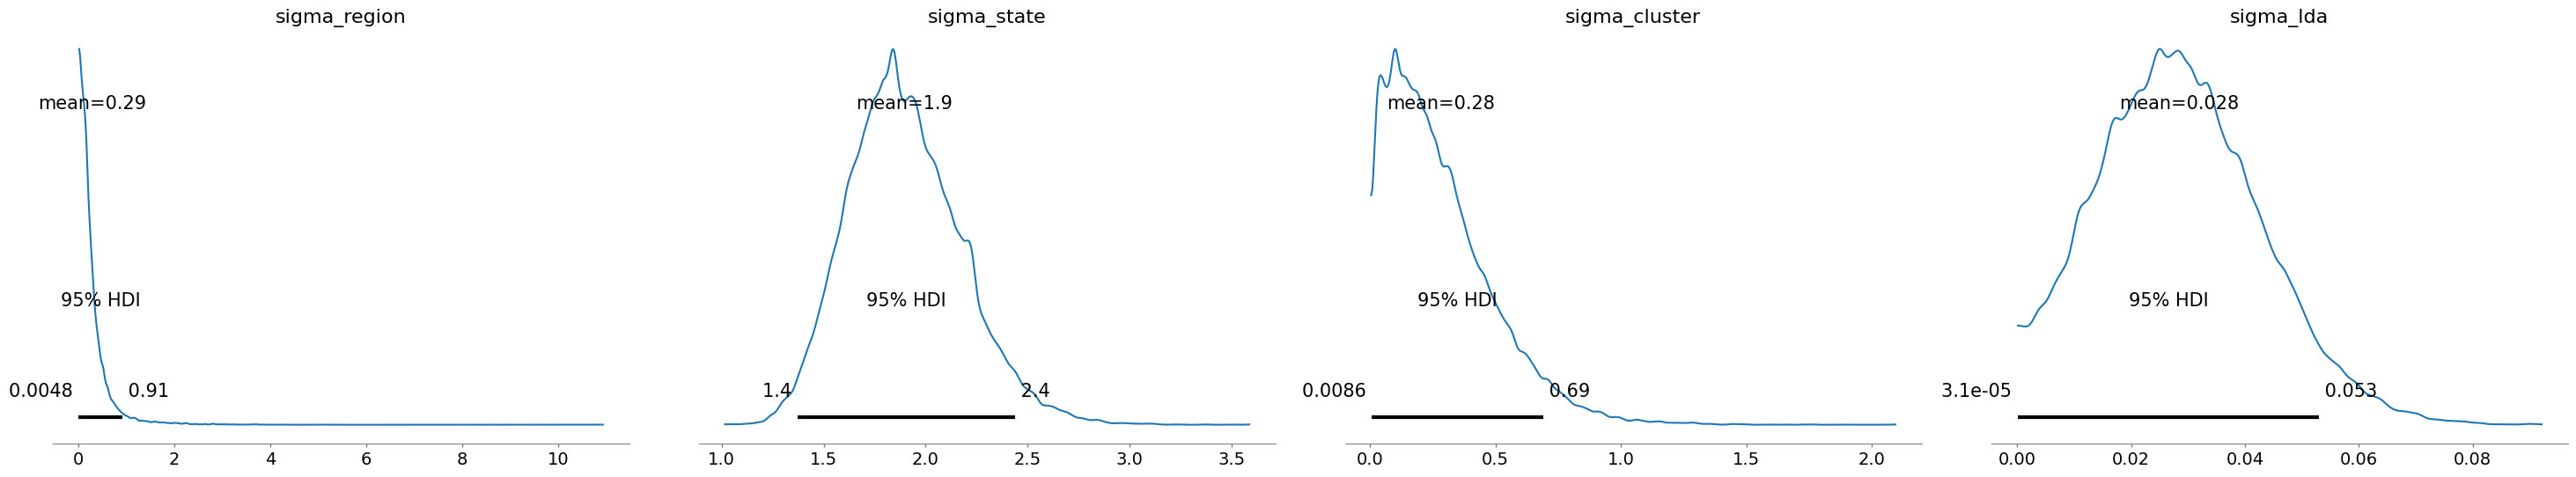

In [10]:
az.plot_posterior(trace, var_names=['sigma_region', 'sigma_state', 'sigma_cluster', 'sigma_lda'], hdi_prob=0.95)
plt.tight_layout()
plt.show()

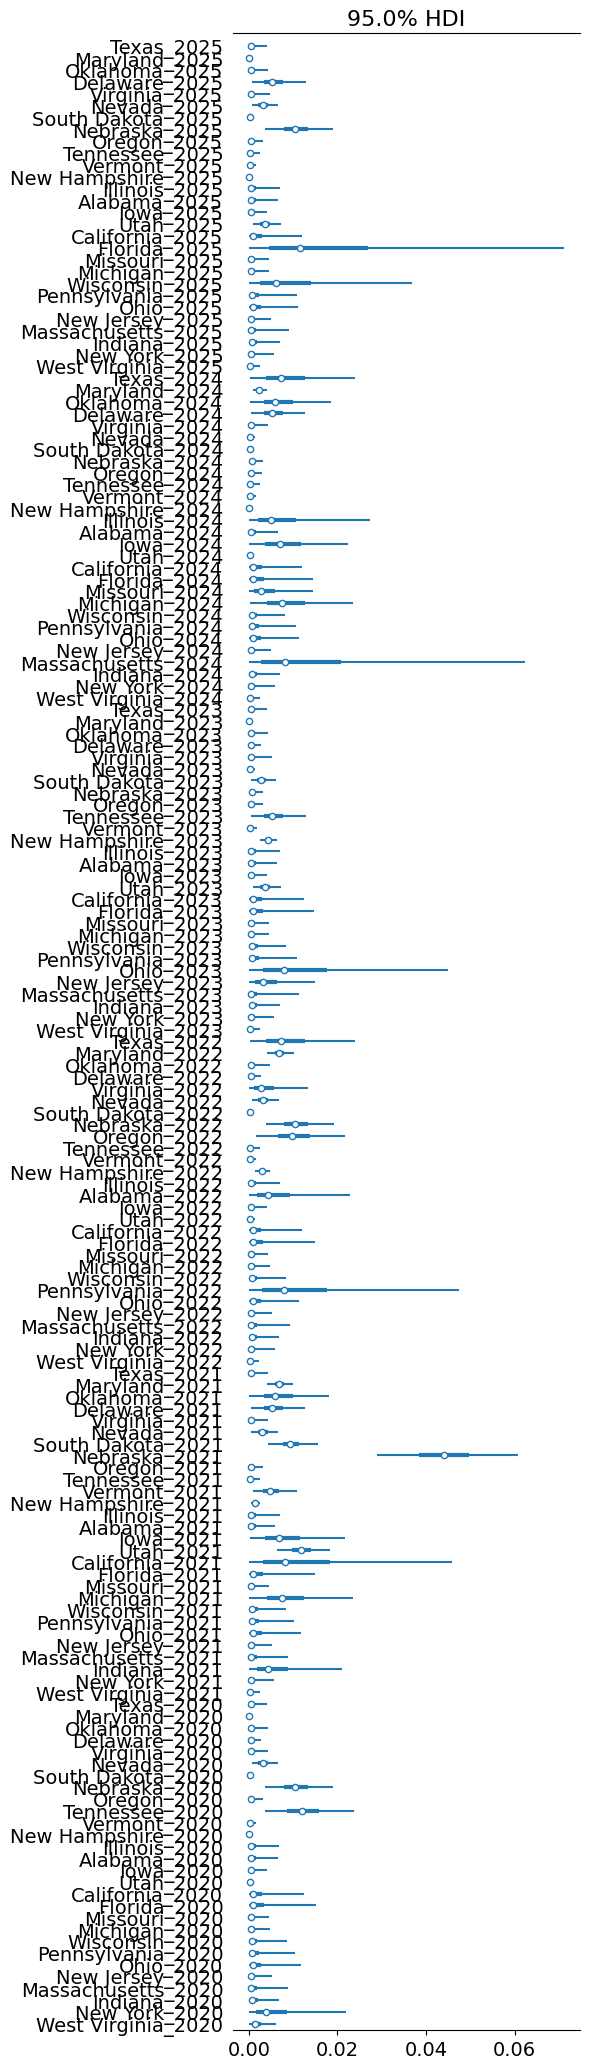

In [11]:
state_probs['state_year'] = state_probs['state'] + '_' + state_probs['year'].astype(str)
ax = az.plot_forest(trace, var_names=['p'], combined=True, hdi_prob=0.95)
ax[0].set_yticklabels(state_probs['state_year'].values)
plt.tight_layout()
plt.show()